# Tutorial 2: Interacting with Zarr

In this notebook, we explore the Zarr products using `xarray`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from panoseti_analysis.io.stores import open_store

## Load L0 (Raw Counts)

In [2]:
l0_store_path = "results_tutorial/L0/obs_TEST.pffd.dp_img16.bpp_2.module_1.debug_TRUNCATED.zarr"
ds_l0 = open_store(l0_store_path)
display(ds_l0)

<xarray.Dataset> Size: 9MB
Dimensions:           (time: 4128, y: 32, x: 32)
Dimensions without coordinates: time, y, x
Data variables: (12/22)
    quabo_2_pkt_num   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_0_pkt_num   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_0_tv_usec   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_0_pkt_nsec  (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_pkt_tai   (time) uint16 8kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_0_pkt_tai   (time) uint16 8kB dask.array<chunksize=(4128,), meta=np.ndarray>
    ...                ...
    quabo_3_tv_sec    (time) int64 33kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_2_tv_sec    (time) int64 33kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_tv_usec   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_2_tv_usec   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_1_tv_usec   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_pkt_num   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
Attributes:
    panoseti_pff_zarr_version:  1.0
    data_product:               img16
    bytes_per_pixel:            2
    module:                     1
    source_pff_files:           ['start_2024-07-25T04_34_46Z.dp_img16.bpp_2.m...
    total_frames:               4128
    header_format:              module
    header_fields:              []
    quabo_fields:               ['quabo_0_pkt_nsec', 'quabo_0_pkt_num', 'quab...
    frame_config:               {'header_size': 491, 'payload_size': 2048, 'f...
    processing_history:         [{'step_name': 'convert', 'step_version': '2....

## Load L1 (Median Subtracted)

In [3]:
l1_store_path = "results_tutorial/L1/obs_TEST.dp_img16.module_1.L1.zarr"
ds_l1 = open_store(l1_store_path)
display(ds_l1)

<xarray.Dataset> Size: 17MB
Dimensions:            (time: 4128, y: 32, x: 32)
Dimensions without coordinates: time, y, x
Data variables: (12/24)
    quabo_0_tv_sec     (time) int64 33kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_pkt_tai    (time) uint16 8kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_0_pkt_nsec   (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_2_pkt_num    (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    dead_pixel_mask    (y, x) uint8 1kB dask.array<chunksize=(32, 32), meta=np.ndarray>
    median_subtracted  (time, y, x) float32 17MB dask.array<chunksize=(4128, 32, 32), meta=np.ndarray>
    ...                 ...
    quabo_1_pkt_tai    (time) uint16 8kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_tv_usec    (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_2_tv_usec    (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    quabo_3_pkt_num    (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
    hot_pixel_mask     (y, x) uint8 1kB dask.array<chunksize=(32, 32), meta=np.ndarray>
    quabo_1_tv_usec    (time) uint32 17kB dask.array<chunksize=(4128,), meta=np.ndarray>
Attributes: (12/15)
    panoseti_pff_zarr_version:          1.0
    data_product:                       img16
    bytes_per_pixel:                    2
    module:                             1
    source_pff_files:                   ['start_2024-07-25T04_34_46Z.dp_img16...
    total_frames:                       4128
    ...                                 ...
    frame_config:                       {'header_size': 491, 'payload_size': ...
    processing_history:                 [{'step_name': 'convert', 'step_versi...
    data_level:                         L1
    panoseti_analysis_storage_version:  2.0
    calibration:                        {'kind': 'img', 'frame_stride': 50, '...
    timestamp_qc:                       {'status': 'clean', 'monotonic': True...

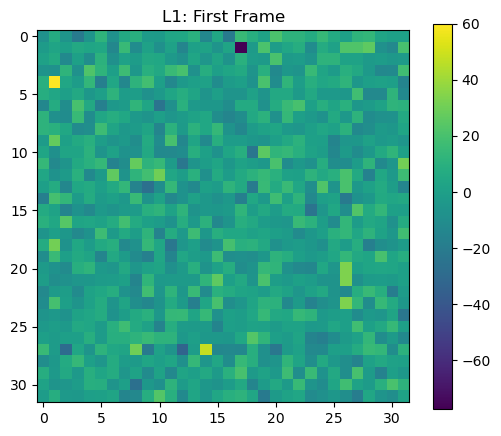

In [4]:
plt.figure(figsize=(6,5))
plt.imshow(ds_l1["median_subtracted"].values[0], cmap="viridis")
plt.colorbar()
plt.title("L1: First Frame")
plt.show()

## Load L2 (Cloud Detection Scores)

In [5]:
l2_store_path = "results_tutorial/L2/obs_TEST.cloud.module_1.zarr"
ds_l2 = open_store(l2_store_path)
display(ds_l2)

<xarray.Dataset> Size: 8kB
Dimensions:            (T_l2: 1, H: 32, W: 32)
Dimensions without coordinates: T_l2, H, W
Data variables:
    feature_raw_fft    (T_l2, H, W) float32 4kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
    cloud_score        (T_l2) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    unix_t_ns          (T_l2) int64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    cloud_label        (T_l2) uint8 1B dask.array<chunksize=(1,), meta=np.ndarray>
    feature_deriv_fft  (T_l2, H, W) float32 4kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
Attributes: (12/15)
    panoseti_pff_zarr_version:          1.0
    data_product:                       img16
    bytes_per_pixel:                    2
    module:                             1
    source_pff_files:                   ['start_2024-07-25T04_34_46Z.dp_img16...
    total_frames:                       4128
    ...                                 ...
    frame_config:                       {'header_size': 491, 'payload_size': ...
    processing_history:                 [{'step_name': 'convert', 'step_versi...
    data_level:                         L2
    panoseti_analysis_storage_version:  2.0
    calibration:                        {'kind': 'img', 'frame_stride': 50, '...
    timestamp_qc:                       {'status': 'clean', 'monotonic': True...

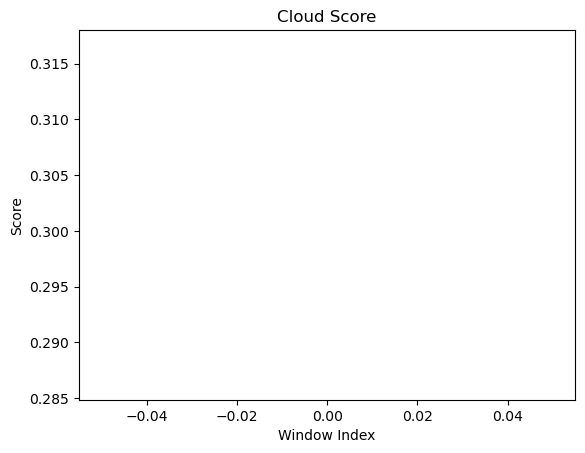

In [6]:
plt.plot(ds_l2["cloud_score"].values)
plt.title("Cloud Score")
plt.xlabel("Window Index")
plt.ylabel("Score")
plt.show()